<a href="https://colab.research.google.com/github/badBrock/MultiHeadAttentionJourney/blob/main/Tried_The_new_PaddleOCR_VL_1_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# CELL 1: Install Dependencies (Fixed)
# ============================================================

# Fix stale apt cache first, then install poppler
!apt-get update -q && apt-get install -y poppler-utils -q

!pip install "transformers>=5.0.0" -q
!pip install accelerate -q
!pip install Pillow -q
!pip install pdf2image -q

# Verify poppler installed correctly
!which pdfinfo && pdfinfo --version

print("✅ All dependencies installed.")
print("   → Go to Runtime > Restart Session, then run from Cell 2.")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,611 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,489 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu ja

In [3]:
# ============================================================
# CELL 2: Configuration — Change settings here
# ============================================================

# --- Input ---
PDF_PATH = "/content/201808%14411_part1.pdf"   # ← Upload your PDF to Colab and update this path

# --- Task Selection ---
# Options: 'ocr' | 'table' | 'chart' | 'formula' | 'spotting' | 'seal'
# Changing task has NO latency effect by itself, but 'spotting' uses
# higher resolution (2x upscale + more pixels) → ~30–50% slower
TASK = "ocr"

# --- PDF → Image Settings ---
# DPI: Higher = better OCR accuracy but slower conversion + more memory
# 150 DPI → fast, good for clean printed text
# 200 DPI → balanced (recommended default)
# 300 DPI → best quality, slower, higher RAM usage
PDF_DPI = 200

# --- Page Range ---
# None = process all pages
# (1, 3) = process pages 1 to 3 only (1-indexed)
# Latency impact: LINEAR — each extra page = one model inference call
PAGE_RANGE = None  # e.g. (1, 2) to test with just first 2 pages

# --- Model ---
MODEL_PATH = "PaddlePaddle/PaddleOCR-VL-1.6"  # Don't change unless testing a different checkpoint

# --- Generation ---
# Max tokens the model will output per page
# Lower = faster but may cut off long text blocks
# Latency impact: directly affects decode time
MAX_NEW_TOKENS = 512  # increase to 1024 for dense/long pages

# --- Precision ---
# "bfloat16" → recommended for T4/A100 (good speed + accuracy)
# "float32"  → more stable on CPU or older GPUs, but ~2x slower and more VRAM
import torch
TORCH_DTYPE = torch.bfloat16

# --- Flash Attention ---
# Set to "flash_attention_2" if you installed flash-attn in Cell 1
# Otherwise leave as "eager"
# Latency impact: flash_attention_2 can be 20–40% faster on long sequences
ATTN_IMPL = "eager"   # or "flash_attention_2"

print("✅ Configuration loaded.")
print(f"   Task: {TASK} | DPI: {PDF_DPI} | Max tokens: {MAX_NEW_TOKENS} | Attention: {ATTN_IMPL}")

✅ Configuration loaded.
   Task: ocr | DPI: 200 | Max tokens: 512 | Attention: eager


📄 Converting PDF to images at 200 DPI...
   → 2 page(s) converted.


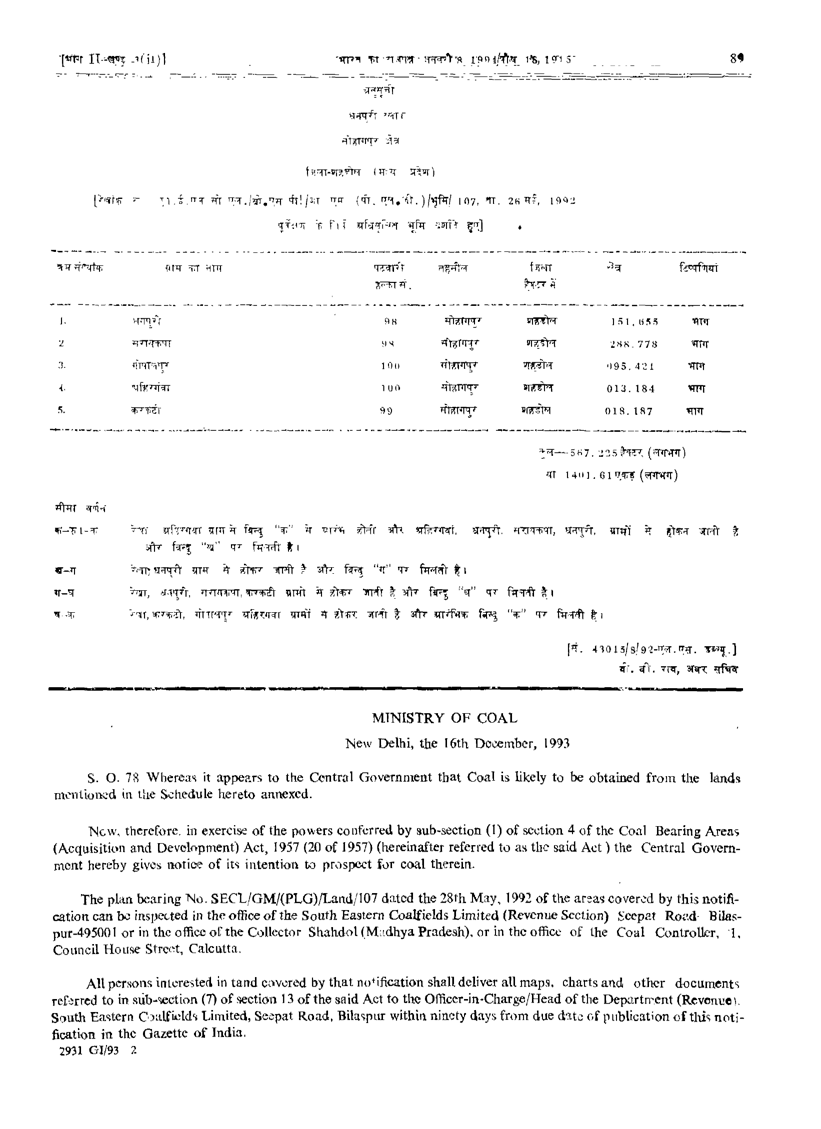

In [5]:
# ============================================================
# CELL 3: PDF → Images
# ============================================================

from pdf2image import convert_from_path
from PIL import Image

def pdf_to_images(pdf_path, dpi=200, page_range=None):
    """
    Convert a PDF to a list of PIL Images.
    page_range: None for all pages, or (first, last) tuple (1-indexed).
    """
    kwargs = {"dpi": dpi, "fmt": "RGB"}
    if page_range:
        kwargs["first_page"] = page_range[0]
        kwargs["last_page"] = page_range[1]

    print(f"📄 Converting PDF to images at {dpi} DPI...")
    images = convert_from_path(pdf_path, **kwargs)
    print(f"   → {len(images)} page(s) converted.")
    return images

pages = pdf_to_images(PDF_PATH, dpi=PDF_DPI, page_range=PAGE_RANGE)

# Preview the first page (optional — comment out if not needed)
display(pages[0].resize((pages[0].width // 2, pages[0].height // 2)))

In [6]:
# ============================================================
# CELL 4: Load Model & Processor
# Run once — reuse across multiple pages / tasks
# ============================================================

from transformers import AutoProcessor, AutoModelForImageTextToText

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {DEVICE}")
if DEVICE == "cpu":
    print("⚠️  No GPU detected. Inference will be very slow. Make sure Runtime > Change runtime type > T4 GPU is selected.")

print(f"📥 Loading model from {MODEL_PATH} ...")
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    torch_dtype=TORCH_DTYPE,
    attn_implementation=ATTN_IMPL,   # change in Cell 2
).to(DEVICE).eval()

processor = AutoProcessor.from_pretrained(MODEL_PATH)
print("✅ Model loaded and ready.")

🖥️  Device: cuda
📥 Loading model from PaddlePaddle/PaddleOCR-VL-1.6 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'mrope_section'}
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.92G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/1.61M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.2M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/25.4k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

✅ Model loaded and ready.


In [ ]:
# CELL: Quick diagnosis — run immediately after interrupting
!nvidia-smi

import torch
print(f"VRAM used:   {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"VRAM cached: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"How many pages total: {len(pages)}")
print(f"Page 1 size: {pages[0].size}")

Sat Jun 13 16:54:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             33W /   70W |    8069MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# ============================================================
# CELL 5: Strip-based OCR — crops page into readable strips
# Solves: image too small to read vs image too large to process
# ============================================================

import time
import torch
from PIL import Image
from transformers import TextStreamer

# --- Strip settings ---
# Each strip is a horizontal slice of the page
# STRIP_HEIGHT_PX: height of each crop in original page pixels
#   Higher = more context per strip but more tokens → risk of slowdown
#   Lower  = faster but may cut mid-sentence
#   500px on a 2259px page = ~4-5 strips per page
STRIP_HEIGHT_PX = 500

# Resize each strip to this width before sending to model
# 800px wide at strip height gives good text legibility
# Lower = faster, higher = better accuracy on small fonts
STRIP_MAX_SIDE = 800

# Overlap between strips in original pixels — prevents cutting words at boundaries
STRIP_OVERLAP_PX = 40

MIN_PIXELS = 128 * 28 * 28
MAX_PIXELS = 560 * 28 * 28   # keep low — this is what fixed the hanging

PROMPTS = {
    "ocr":      "OCR:",
    "table":    "Table Recognition:",
    "formula":  "Formula Recognition:",
    "chart":    "Chart Recognition:",
    "spotting": "Spotting:",
    "seal":     "Seal Recognition:",
}


def resize_strip(image, max_side=STRIP_MAX_SIDE):
    w, h = image.size
    if max(w, h) <= max_side:
        return image
    scale = max_side / max(w, h)
    try:
        resample = Image.Resampling.LANCZOS
    except AttributeError:
        resample = Image.LANCZOS
    return image.resize((int(w * scale), int(h * scale)), resample)


def crop_into_strips(image, strip_height=STRIP_HEIGHT_PX, overlap=STRIP_OVERLAP_PX):
    """Slice a full page image into overlapping horizontal strips."""
    w, h = image.size
    strips = []
    y = 0
    while y < h:
        y_end = min(y + strip_height, h)
        strip = image.crop((0, y, w, y_end))
        strips.append(strip)
        y += strip_height - overlap  # overlap prevents cutting words at edges
    return strips


def run_model_on_strip(strip, task=TASK):
    """Run model inference on a single strip image."""
    strip = resize_strip(strip)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": strip},
                {"type": "text",  "text": PROMPTS[task]},
            ]
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        processor_kwargs={
            "images_kwargs": {
                "size": {
                    "shortest_edge": MIN_PIXELS,
                    "longest_edge": MAX_PIXELS,
                }
            }
        },
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,   # per strip — strips are short so 256 is enough
            do_sample=False,
            repetition_penalty=1.1,
        )

    result = processor.decode(outputs[0][inputs["input_ids"].shape[-1]:-1])
    return result, inputs["input_ids"].shape[-1]


def process_page(page_image, task=TASK, page_num=1):
    """Process a full page by splitting into strips and combining results."""
    strips = crop_into_strips(page_image)
    print(f"  Page {page_num}: {len(strips)} strips from {page_image.size} px image")

    page_results = []
    for j, strip in enumerate(strips):
        t0 = time.time()
        result, n_tokens = run_model_on_strip(strip, task=task)
        elapsed = time.time() - t0
        print(f"    Strip {j+1}/{len(strips)}: {strip.size}px → {n_tokens} tokens → {elapsed:.1f}s")
        page_results.append(result.strip())

    # Join strips — for OCR just newline, for table we post-process below
    return page_results


def strips_to_html_table(strip_results):
    """
    Convert strip results to a single HTML table.
    The model outputs a custom cell format: <fcel>content<lcel>...<nl><ecel>
    This parser converts it to proper HTML.
    """
    html_rows = []

    for strip_text in strip_results:
        # Split into rows by <nl> or <ecel>
        rows = strip_text.replace("<ecel>", "").split("<nl>")
        for row in rows:
            row = row.strip()
            if not row:
                continue

            # Split cells: <fcel> = first cell, <lcel> = last cell, separator between
            # Format: <fcel>content<lcel>...<lcel>content<lcel>
            cells = []
            parts = row.split("<fcel>")
            for part in parts:
                if not part:
                    continue
                # Each part may contain <lcel> separators
                cell_parts = part.split("<lcel>")
                for cp in cell_parts:
                    cp = cp.strip()
                    if cp:
                        cells.append(f"<td>{cp}</td>")

            if cells:
                html_rows.append(f"  <tr>{''.join(cells)}</tr>")

    if not html_rows:
        return "<p>No table content found</p>"

    return "<table border='1'>\n" + "\n".join(html_rows) + "\n</table>"


def strips_to_text(strip_results):
    """Combine OCR strip results into plain text."""
    return "\n".join(strip_results)


# ============================================================
# Run on all pages
# ============================================================

all_results = []     # raw strip results per page
all_html    = []     # HTML tables per page (if task=table)
all_text    = []     # plain text per page  (if task=ocr)

for i, page_image in enumerate(pages):
    page_num = (PAGE_RANGE[0] + i) if PAGE_RANGE else (i + 1)
    t0 = time.time()
    print(f"\n📄 Processing page {page_num}/{len(pages)}...")

    strip_results = process_page(page_image, task=TASK, page_num=page_num)
    all_results.append(strip_results)

    if TASK == "table":
        html = strips_to_html_table(strip_results)
        all_html.append(html)
        print(f"\n  HTML preview (first 300 chars):\n  {html[:300]}")
    else:
        text = strips_to_text(strip_results)
        all_text.append(text)
        print(f"\n  Text preview:\n  {text[:300]}")

    print(f"  ✅ Page {page_num} done in {time.time()-t0:.1f}s")

print("\n✅ All pages processed.")


📄 Processing page 1/2...
  Page 1: 5 strips from (1642, 2259) px image
    Strip 1/5: (1642, 500)px → 274 tokens → 165.7s
    Strip 2/5: (1642, 500)px → 274 tokens → 165.1s
    Strip 3/5: (1642, 500)px → 274 tokens → 134.2s
    Strip 4/5: (1642, 500)px → 274 tokens → 152.4s
    Strip 5/5: (1642, 419)px → 216 tokens → 69.9s

  Text preview:
  [ऽག 11-སྐུ འདྲ སརྒ་ཏ། ༡༠༥༢ལོར་ཁྱབ ༡༩༣༦ལོ་ནི་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའོ་ཀེ་ལུའ
ऐसा संबंधक  याप  का  भय  परबर्जी  तृद्रानि  अह्मिन  हिंशा  जेः  टिशनिया

1.  आगड़ी  98  म
  ✅ Page 1 done in 687.3s

📄 Processing page 2/2...
  Page 2: 5 strips from (1637, 2253) px image
    Strip 1/5: (1637, 500)px → 274 tokens → 110.3s
    Strip 2/5: (1637, 500)px → 274 tokens → 166.1s
    Strip 3/5: (1637, 500)px → 274 tokens → 170.5s
    Strip 4/5: (1637, 500)px → 274 tokens → 170.5s
    Strip 5/5: (1637, 413)px → 216 tokens → 127.3s



In [9]:
# ============================================================
# CELL 6: Save as Markdown with embedded HTML tables
# ============================================================

OUTPUT_PATH = "/content/ocr_results.md"

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    f.write(f"# OCR Results\n\n")
    f.write(f"**Task:** `{TASK}`  \n**Source:** `{PDF_PATH}`\n\n---\n\n")

    for i in range(len(pages)):
        page_num = (PAGE_RANGE[0] + i) if PAGE_RANGE else (i + 1)
        f.write(f"## Page {page_num}\n\n")

        if TASK == "table":
            f.write(all_html[i])
        else:
            f.write(f"```\n{all_text[i]}\n```")

        f.write("\n\n---\n\n")

print(f"✅ Saved to {OUTPUT_PATH}")

from google.colab import files
files.download(OUTPUT_PATH)

✅ Saved to /content/ocr_results.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>